In [1]:
import numpy as np
from TestAv2 import TestAv2RL
from stable_baselines3 import PPO
from gym_pybullet_drones.envs.BaseAviary import DroneModel

In [2]:
ep_len = 2 # sec

drone_model = DroneModel.CF2X

env = TestAv2RL(drone_model=drone_model, ep_len=ep_len, freq=240)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [3]:
import os
from stable_baselines3.common.monitor import Monitor

exp_name = "Av2PPO5"
log_dir = "C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/AttitudeThroughPosition/attitude_sb3_logs" + "/" + exp_name
os.makedirs(log_dir, exist_ok=True)
env = Monitor(env, log_dir)

In [4]:
from stable_baselines3.common.callbacks import EvalCallback
eval_env = TestAv2RL(drone_model=drone_model, ep_len=ep_len, freq=240)
eval_env = Monitor(eval_env)

eval_callback = EvalCallback(eval_env,
            log_path=log_dir,
            n_eval_episodes=2,
            eval_freq=1000,
            deterministic=True) 

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


In [5]:
policy_kwargs = dict(net_arch=[dict(pi=[128, 128, 128], vf=[128, 128, 128])])
model = PPO('MlpPolicy', env, policy_kwargs=policy_kwargs, verbose=0)
model.learn(total_timesteps=500000, callback=eval_callback)

Eval num_timesteps=1000, episode_reward=-62.96 +/- 16.08
Episode length: 481.00 +/- 0.00
New best mean reward!
Eval num_timesteps=2000, episode_reward=-55.84 +/- 24.00
Episode length: 481.00 +/- 0.00
New best mean reward!
Eval num_timesteps=3000, episode_reward=-58.28 +/- 8.03
Episode length: 481.00 +/- 0.00
Eval num_timesteps=4000, episode_reward=-45.48 +/- 14.87
Episode length: 481.00 +/- 0.00
New best mean reward!
Eval num_timesteps=5000, episode_reward=-623.07 +/- 5.29
Episode length: 481.00 +/- 0.00
Eval num_timesteps=6000, episode_reward=-610.08 +/- 6.13
Episode length: 481.00 +/- 0.00
Eval num_timesteps=7000, episode_reward=-796.38 +/- 23.38
Episode length: 481.00 +/- 0.00
Eval num_timesteps=8000, episode_reward=-779.30 +/- 4.32
Episode length: 481.00 +/- 0.00
Eval num_timesteps=9000, episode_reward=-1024.85 +/- 6.85
Episode length: 481.00 +/- 0.00
Eval num_timesteps=10000, episode_reward=-1013.59 +/- 18.73
Episode length: 481.00 +/- 0.00
Eval num_timesteps=11000, episode_reward

In [6]:
model.save(log_dir + "/model")

In [7]:
history = np.load(log_dir + "/evaluations.npz")
rewards = np.average(history["results"], axis=1)
print(rewards.shape)

(1001,)


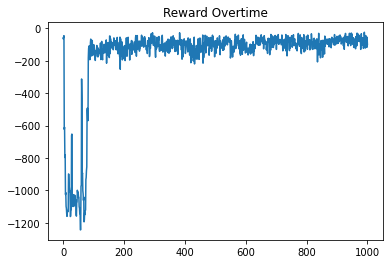

In [8]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.title("Reward History")
plt.xlabel("Episodes(x1000)")
plt.ylabel("Reward")
plt.show()

In [9]:
ep_len = 2 # sec

cumm_reward = 0
curr_rpys = []
computed_target_rpys = []
obs = env.reset()
for i in range(ep_len*env.SIM_FREQ):

    # computing next action
    action, _ = model.predict(obs)
    
    # stepping the environment
    obs, reward, done, info = env.step(action)

    # extracting relevant info
    computed_target_rpys.append(info['target_rpy'])
    curr_rpys.append(info['curr_rpy'])

    # accumulating reward over episode
    cumm_reward += reward

print(cumm_reward)

-21.722976163020046


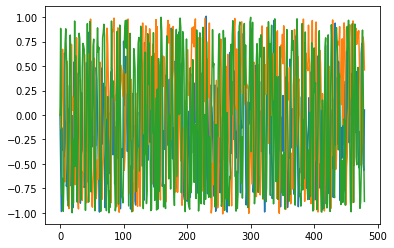

In [10]:
rpy_errs = np.array(computed_target_rpys)-np.array(curr_rpys)
plt.plot(rpy_errs)
plt.show()

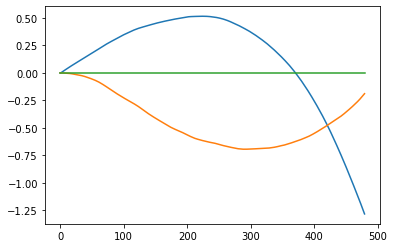

In [11]:
plt.plot(np.array(computed_target_rpys)*180/np.pi)
plt.show()